**GRB clustering**

Discover clustering methods and conclude with some observation about Gamma-Ray-Bust.

In [71]:
import numpy as np
import matplotlib.pyplot as plt

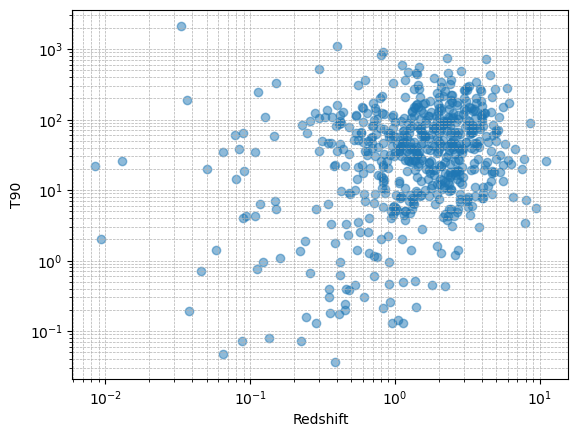

In [76]:
dataRed = np.loadtxt('GRB_Red_T90.txt')
dataRedMask = np.copy(dataRed[:, [0, 1]])

plt.scatter(dataRedMask[:, 0], dataRedMask[:, 1], alpha=0.5)
plt.xlabel('Redshift')
plt.ylabel('T90')
plt.xscale('log')
plt.yscale('log')
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.show()


Preprocessig is need to make work the distance to minimize in the loss function of K-mean.

In [88]:
from sklearn.cluster import KMeans, MeanShift
from sklearn import preprocessing


In [ ]:
nClusters = 5

scaler = preprocessing.StandardScaler()
dataRedML = scaler.fit_transform(dataRedMask)

clKM = KMeans(n_clusters=nClusters, n_init='auto')
clKM.fit(dataRedML)

clMS = MeanShift(bandwidth=1.0)
clMS.fit(dataRedML)

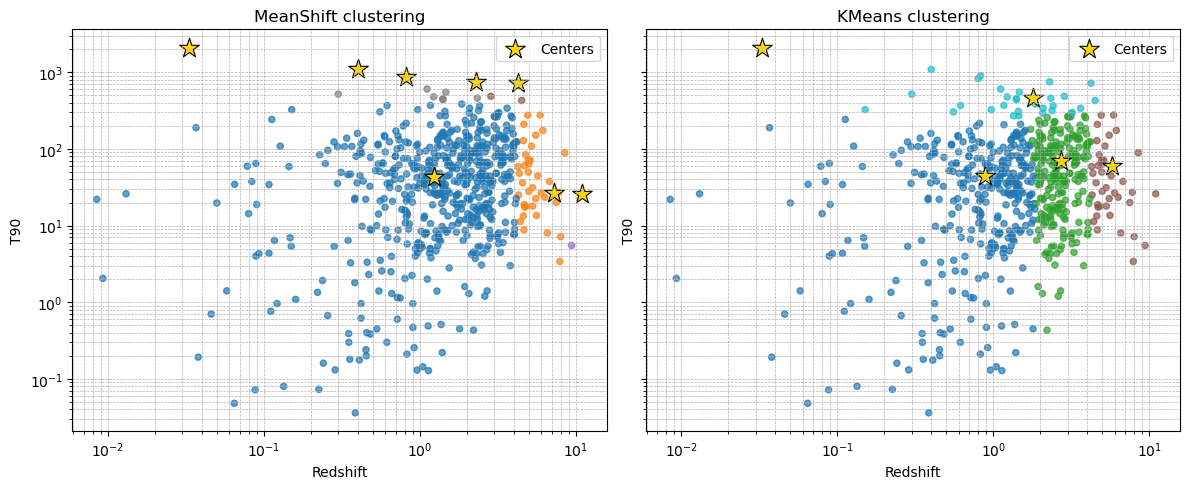

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

axes[0].scatter(dataRedMask[:, 0], dataRedMask[:, 1], c=clMS.predict(dataRedML), cmap='tab10', s=20, alpha=0.7)
axes[0].set_title('MeanShift clustering')
axes[0].set_xlabel('Redshift')
axes[0].set_ylabel('T90')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].grid(True, which='both', linestyle='--', linewidth=0.5)

axes[1].scatter(dataRedMask[:, 0], dataRedMask[:, 1], c=clKM.predict(dataRedML), cmap='tab10', s=20, alpha=0.7)
axes[1].set_title('KMeans clustering')
axes[1].set_xlabel('Redshift')
axes[1].set_ylabel('T90')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].grid(True, which='both', linestyle='--', linewidth=0.5)

centersKM = scaler.inverse_transform(clKM.cluster_centers_)
centersMS = scaler.inverse_transform(clMS.cluster_centers_)

axes[0].scatter(
    centersMS[:, 0], centersMS[:, 1],
    marker='*', s=220, c='gold', edgecolors='black', linewidths=0.8, label='Centers'
)
axes[1].scatter(
    centersKM[:, 0], centersKM[:, 1],
    marker='*', s=220, c='gold', edgecolors='black', linewidths=0.8, label='Centers'
)

axes[0].legend()
axes[1].legend()

plt.tight_layout()
plt.show()

*Comment:*

It's an unsupervised learning: we are sensible on number of cluster wich can we fix with cross validation. Comparison beetween the two method is difficult becouse of different loss function; there are still method probabily in the licterature.

MeanShift is very sensible to bandwith input.

When Cluster a singole point could be used as a method to fix outliers?

**Furter Analysis: Fluence and T90**

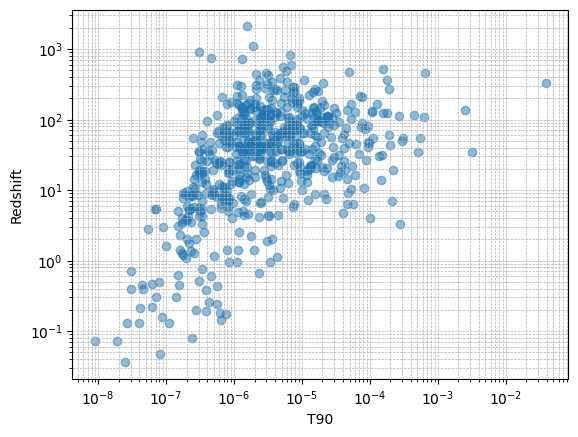

In [74]:
dataF = np.loadtxt('GRB_Fluence_T90.txt')

plt.scatter(dataF[:, 0], dataF[:, 1], alpha=0.5)
plt.title('')
plt.xlabel('T90')
plt.ylabel('Redshift')
plt.xscale('log')
plt.yscale('log')
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.show()


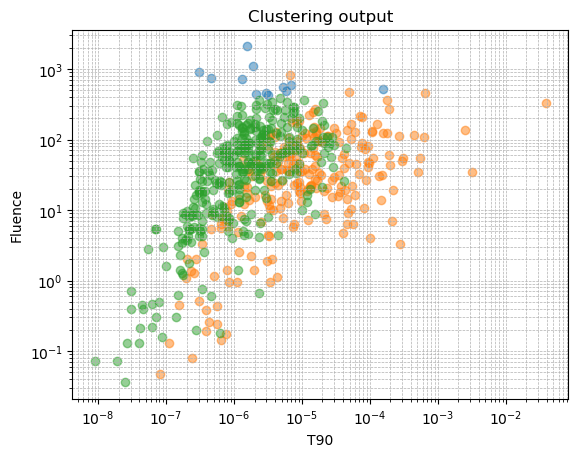

In [75]:
clKM.fit(dataF)
centers = clKM.cluster_centers_ 
labels = clKM.predict(dataF) 

colors = ['C1', 'C0', 'C2']
for ii in range(3):
    plt.scatter(dataF[labels==ii,0], dataF[labels==ii,1], color=colors[ii],alpha=0.5)

plt.title('Clustering output')
plt.xlabel('T90')
plt.ylabel('Fluence')
plt.xscale('log')
plt.yscale('log')
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.show()